# Dérive des données et réapprentissages successifs

Un modèle mis en production se dégrade avec le temps : les données changent (dérive des données) et la relation entre les entrées et la sortie aussi (dérive des concepts).

Dans cette démonstration, nous prévoyons le nombre de vélos loués chaque heure à Washington (2011–2012) et comparons trois politiques de réapprentissage :

- **Jamais** : le modèle initial reste en production
- **Chaque mois** : on réapprend sur toutes les données disponibles, tous les mois
- **Sur dégradation** : on réapprend seulement quand l'erreur mesurée augmente nettement

In [1]:
!pip install -q "evidently>=0.7,<0.8"

import warnings

import matplotlib.pyplot as plt
import pandas as pd
from evidently import DataDefinition, Dataset, Report
from evidently.presets import DataDriftPreset
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

warnings.filterwarnings("ignore")

# Textes affichés dans les graphiques et les tableaux
YLABEL_RENTALS = "Locations par heure (moyenne)"
XLABEL_MONTH = "Mois"
TITLE_CONCEPT = "Locations moyennes par mois"
MSG_TRAINED = "Modèle appris sur {} heures de données"
LEGEND = ["Jamais", "Chaque mois", "Sur dégradation"]
YLABEL_MAE = "MAE (vélos par heure)"
TITLE_POLICIES = "Erreur mensuelle selon la politique de réapprentissage (pointillés : réapprentissages)"
COL_MAE = "MAE moyenne"
COL_RETRAINS = "Réapprentissages"

## Les données

Le jeu de données [*Bike Sharing*](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset) donne, pour chaque heure, la météo, le calendrier et le nombre de locations (`cnt`, la valeur à prédire).

In [2]:
df = pd.read_csv(
    "https://github.com/shuuchuu/datasets/raw/refs/heads/main/bike-sharing/hour.csv", parse_dates=["dteday"]
)
df["month"] = df["dteday"].dt.to_period("M")

FEATURES = ["temp", "atemp", "hum", "windspeed", "hr", "weekday", "workingday",
            "holiday", "weathersit"]
WEATHER = ["temp", "atemp", "hum", "windspeed"]
TARGET = "cnt"
df[["dteday", *FEATURES, TARGET]].head()

,dteday,temp,atemp,hum,windspeed,hr,weekday,workingday,holiday,weathersit,cnt
0,2011-01-01,0.24,0.2879,0.81,0.0,0,6,0,0,1,16
1,2011-01-01,0.22,0.2727,0.80,0.0,1,6,0,0,1,40
2,2011-01-01,0.22,0.2727,0.80,0.0,2,6,0,0,1,32
3,2011-01-01,0.24,0.2879,0.75,0.0,3,6,0,0,1,13
4,2011-01-01,0.24,0.2879,0.75,0.0,4,6,0,0,1,1


## Une dérive des concepts : le service devient populaire

À météo égale, on loue beaucoup plus de vélos en 2012 qu'en 2011 : la relation entre les entrées et la sortie a changé. Aucune variable d'entrée ne permet au modèle de le voir.

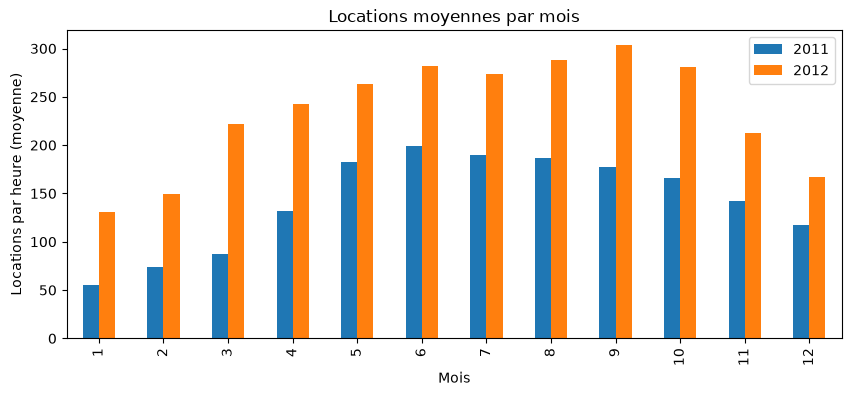

In [3]:
monthly = df.groupby(["yr", "mnth"])[TARGET].mean().unstack(0)
monthly.columns = ["2011", "2012"]
monthly.plot(kind="bar", figsize=(10, 4), ylabel=YLABEL_RENTALS, xlabel=XLABEL_MONTH)
plt.title(TITLE_CONCEPT)
plt.show()

## Un premier modèle, appris sur janvier et février 2011

In [4]:
def train(data: pd.DataFrame) -> RandomForestRegressor:
    model = RandomForestRegressor(n_estimators=100, min_samples_leaf=5, n_jobs=-1,
                                  random_state=0)
    model.fit(data[FEATURES], data[TARGET])
    return model


months = sorted(df["month"].unique())
initial = df[df["month"].isin(months[:2])]
model = train(initial)
print(MSG_TRAINED.format(len(initial)))

Modèle appris sur 1337 heures de données


## Détecter une dérive des données avec `evidently`

Comparons la météo de juillet 2011 à celle des données d'apprentissage :

In [5]:
definition = DataDefinition(numerical_columns=WEATHER)
july = df[df["month"] == pd.Period("2011-07")]
report = Report([DataDriftPreset()])
run = report.run(
    reference_data=Dataset.from_pandas(initial[WEATHER], data_definition=definition),
    current_data=Dataset.from_pandas(july[WEATHER], data_definition=definition),
)
run

La dérive est massive : il fait bien plus chaud en juillet qu'en hiver. C'est pourtant une dérive **attendue** (les saisons) : une alerte de dérive est un signal à analyser, pas une raison suffisante pour réapprendre. Le critère décisif est la performance mesurée, dès que les vraies valeurs sont connues.

## Comparer trois politiques de réapprentissage

Chaque mois, le modèle en production prédit, puis les vraies locations sont connues : on mesure l'erreur absolue moyenne (MAE, en vélos par heure) et chaque politique décide de réapprendre ou non.

In [6]:
def mae(model: RandomForestRegressor, data: pd.DataFrame) -> float:
    return mean_absolute_error(data[TARGET], model.predict(data[FEATURES]))


never = monthly_model = perf_model = model
seen = initial.copy()
baseline = None
rows = []
for month in months[2:]:
    batch = df[df["month"] == month]
    # 1. Les prédictions du mois sont faites, puis les vraies valeurs arrivent
    row = {"month": str(month), "never": mae(never, batch),
           "monthly": mae(monthly_model, batch), "on_degradation": mae(perf_model, batch)}
    seen = pd.concat([seen, batch])
    # 2. Politique « chaque mois » : on réapprend systématiquement
    monthly_model = train(seen)
    # 3. Politique « sur dégradation » : on réapprend si l'erreur dépasse de 25 %
    #    celle mesurée juste après le dernier apprentissage
    if baseline is None:
        baseline = row["on_degradation"]
    row["retrained"] = row["on_degradation"] > 1.25 * baseline
    if row["retrained"]:
        perf_model = train(seen)
        baseline = None
    rows.append(row)

results = pd.DataFrame(rows).set_index("month")
results.round(1)

,never,monthly,on_degradation,retrained
month,,,,
2011-03,25.1,25.1,25.1,False
2011-04,61.9,50.3,61.9,True
2011-05,101.1,48.4,48.4,False
2011-06,107.8,32.6,53.6,False
2011-07,98.0,29.4,55.2,False
2011-08,98.9,29.8,52.6,False
2011-09,104.3,35.8,52.8,False
2011-10,89.3,42.7,52.3,False
2011-11,70.3,43.3,52.8,False


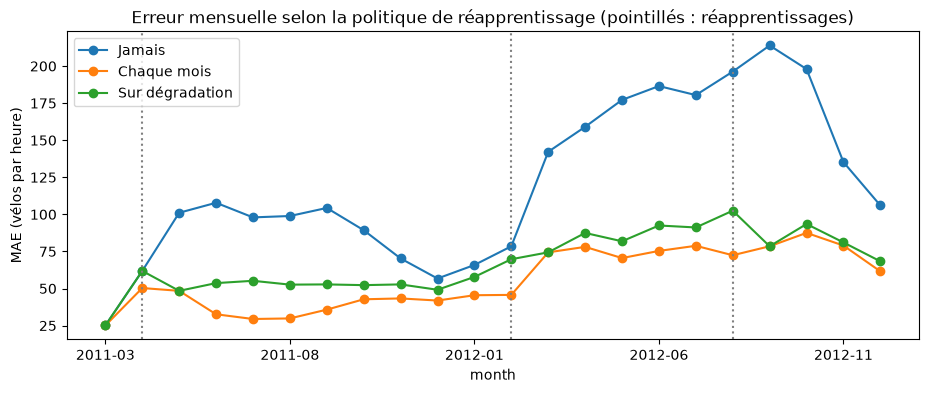

In [7]:
ax = results[["never", "monthly", "on_degradation"]].plot(figsize=(11, 4), marker="o")
ax.legend(LEGEND)
for i, retrained in enumerate(results["retrained"]):
    if retrained:
        ax.axvline(i, color="grey", linestyle=":")
ax.set_ylabel(YLABEL_MAE)
plt.title(TITLE_POLICIES)
plt.show()

In [8]:
summary = pd.DataFrame({
    COL_MAE: results[["never", "monthly", "on_degradation"]].mean().round(1).values,
    COL_RETRAINS: [0, len(results), int(results["retrained"].sum())],
}, index=LEGEND)
summary

,MAE moyenne,Réapprentissages
Jamais,120.6,0
Chaque mois,55.8,22
Sur dégradation,67.4,3


## À retenir

- Sans réapprentissage, l'erreur explose : de 25 à plus de 200 vélos par heure
- Réapprendre chaque mois donne la meilleure erreur, mais coûte 22 apprentissages, déploiements et validations
- Réapprendre sur dégradation obtient l'essentiel du gain avec une poignée de réapprentissages
- Dans tous les cas, il faut **mesurer** la performance en production : c'est elle qui déclenche l'action